# **Import Statements**

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Data Processing**

**Load in dataset and use pandas.get_dummies to construct discrete numeric variables**

In [3]:
nyar_df = pd.read_csv('/content/drive/MyDrive/NYPD_Arrests_Data_ML.csv',on_bad_lines="warn",engine='python')
nyar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2374606 entries, 0 to 2374605
Data columns (total 19 columns):
 #   Column             Dtype  
---  ------             -----  
 0   ARREST_KEY         int64  
 1   ARREST_DATE        object 
 2   PD_CD              float64
 3   PD_DESC            object 
 4   KY_CD              float64
 5   OFNS_DESC          object 
 6   LAW_CODE           object 
 7   LAW_CAT_CD         object 
 8   ARREST_BORO        object 
 9   ARREST_PRECINCT    int64  
 10  JURISDICTION_CODE  int64  
 11  AGE_GROUP          object 
 12  PERP_SEX           object 
 13  PERP_RACE          object 
 14  X_COORD_CD         float64
 15  Y_COORD_CD         float64
 16  Latitude           float64
 17  Longitude          float64
 18  Lon_Lat            object 
dtypes: float64(6), int64(3), object(10)
memory usage: 344.2+ MB


In [4]:
# selecting cols
nyar_df = nyar_df[['ARREST_DATE','ARREST_BORO','AGE_GROUP','PERP_SEX','PERP_RACE','LAW_CAT_CD']]

# cleaning empty rows
nyar_df = nyar_df.dropna()

**Using dummies allows us to easily transform categories like age, race, sex, and location into discrete features**

In [5]:
# creating our "dummy" variables
dummies = pd.get_dummies(
    nyar_df[['AGE_GROUP', 'PERP_RACE', 'PERP_SEX', 'ARREST_BORO']],
    prefix=['AGE', 'RACE', 'SEX', 'BORO']
).astype(int)

nyar_df = pd.concat([nyar_df, dummies], axis=1)

**Below, we update our column names**

In [6]:
# renaming columns
rename_map = {
    'AGE_18-24': 'IS_18_TO_24', # AGE COLS
    'AGE_25-44': 'IS_25_TO_44',
    'AGE_45-64': 'IS_45_TO_64',
    'AGE_65+': 'IS_65_PLUS',

    'RACE_BLACK HISPANIC': 'IS_BLACK_HISPANIC', # RACE COLS
    'RACE_BLACK': 'IS_BLACK',
    'RACE_WHITE HISPANIC': 'IS_WHITE_HISPANIC',
    'RACE_WHITE': 'IS_WHITE',
    'RACE_ASIAN / PACIFIC ISLANDER': 'IS_AAPI',
    'RACE_AMERICAN INDIAN/ALASKAN NATIVE': 'IS_AM_IN_AK_NA',
    'RACE_UNKNOWN': 'RACE_IS_UNKNOWN',

    'SEX_M': 'IS_MALE', # SEX COL

    'BORO_Q': 'IS_QUEENS', # BORO COL
    'BORO_B': 'IS_BRONX',
    'BORO_M': 'IS_MANH',
    'BORO_K': 'IS_BROOK',
    'BORO_S': 'IS_STATEN'
}

nyar_df = nyar_df.rename(columns=rename_map)

**Here we do other processing, like removing minors from our modeling, updating our date variable and filtering by year, and removing some null or extraneous categories from our target variable.**

In [7]:
# filtering minors from database
nyar_df = nyar_df[nyar_df['AGE_GROUP'] != '<18']

# converting ARREST_DATE to binary discrete variable with 2023 and 2024 datapoints
nyar_df['date_col'] = pd.to_datetime(nyar_df['ARREST_DATE'], format='mixed')
nyar_df = nyar_df[nyar_df['date_col'].dt.year.isin([2023, 2024])]

# removing null values for offense level
nyar_df = nyar_df[~nyar_df['LAW_CAT_CD'].isin(['(null)', 9, 'I'])]

In [8]:
# seperating some data for reporting accuracy by borough, race, and sex
borough_cols = ['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK','IS_STATEN']
borough_data = nyar_df[borough_cols]

race_cols = [
    'IS_BLACK_HISPANIC',
    'IS_BLACK',
    'IS_WHITE_HISPANIC',
    'IS_WHITE',
    'IS_AAPI',
    'IS_AM_IN_AK_NA',
    'RACE_IS_UNKNOWN'
]
race_data = nyar_df[race_cols]

sex_cols = ['IS_MALE']
sex_data = nyar_df[sex_cols]

# **Random Forest Classifier (RFC)**


In [62]:
# selecting features
selected_features = ['IS_QUEENS','IS_BRONX','IS_MANH','IS_BROOK','IS_STATEN',
            'IS_18_TO_24','IS_25_TO_44','IS_45_TO_64','IS_65_PLUS',
            'IS_BLACK_HISPANIC','IS_BLACK','IS_WHITE_HISPANIC','IS_WHITE','IS_AAPI','IS_AM_IN_AK_NA', 'IS_MALE']
X = nyar_df[selected_features]

# selecting target
y = nyar_df['LAW_CAT_CD']

# Drop rows where target variable 'y' is NaN, and apply the same filter to X
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# scaling features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test split with scaled features
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=.2, random_state=42)

# training a base RFC
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [60]:
# predicting
y_pred = rf.predict(X_test)

# basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.5752242778040091
Balanced Accuracy: 0.2580762168445947


**The model accurately predicts offense level ~58% of the time, but only ~25% when measuring balanced accuracy.**

**Below, we begin to model how important our features are to our RFC.**

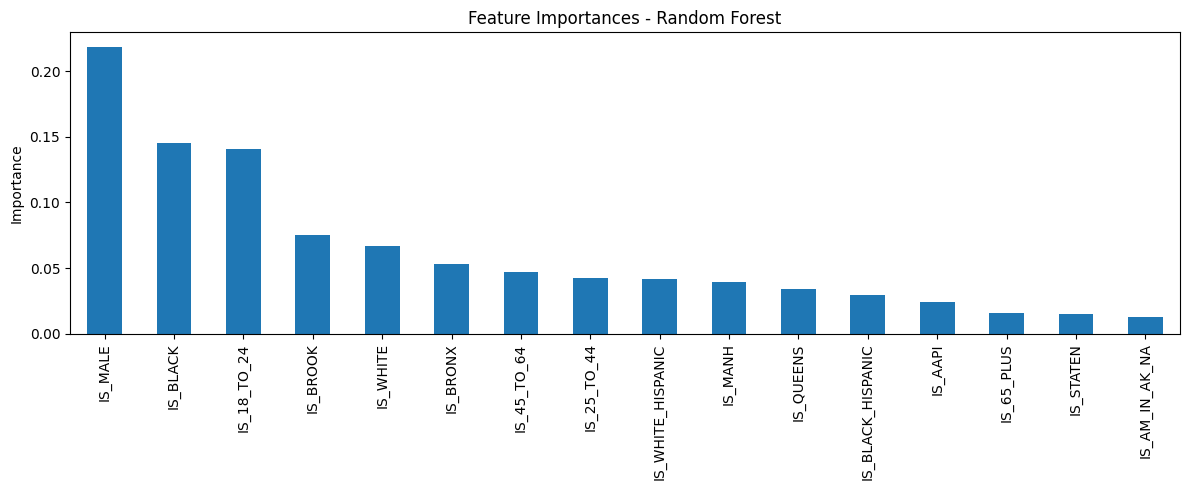

In [ ]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# sorting and plotting
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,5))
plt.title('Feature Importances - Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

**But let's take a look at the distribution of our data**

In [ ]:
print(nyar_df['LAW_CAT_CD'].value_counts())
print(nyar_df['LAW_CAT_CD'].value_counts(normalize=True))

LAW_CAT_CD
M    266315
F    194738
V      3541
9      1342
Name: count, dtype: int64
LAW_CAT_CD
M    0.57157
F    0.41795
V    0.00760
9    0.00288
Name: proportion, dtype: float64


**There is a class imbalance with misdemeanors representing ~57% of the dataset. Let's try another RFC balancing class weights.**


In [ ]:
# setting and fitting
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# predicting
y_pred = rf.predict(X_test)

# base accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.2559020474739237
Balanced Accuracy: 0.49994110070975056


**It's less accurate now, which makes sense. It makes more predictions that are less likely because it was trained with balanced class weights. But our balanced accuracy improved. Let's try it with another RFC, tuning our parameters.**

In [ ]:
rf_tuned = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=200,      # more trees, more computation cost
    max_depth=10,          # limit to reduce overfitting
    min_samples_leaf=5     # requires more samples per leaf
)
rf_tuned.fit(X_train, y_train)

# predicting
y_pred_tuned = rf_tuned.predict(X_test)

# base accuracy
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

# balanced accuracy
print("Tuned Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.25471090698373183
Tuned Balanced Accuracy: 0.5038508997789022


**After tuning, there is a significant improvement in accuracy scores. This suggests that when our data is balanced, our model can correctly train and predict offense level with a 50% balanced accuracy. We can visualize performance here using a useful confusion matrix.**

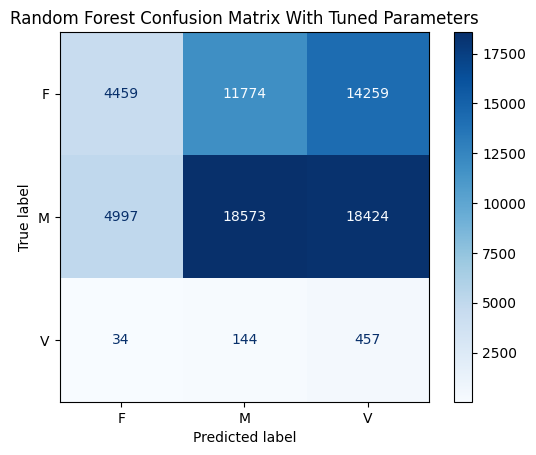

In [ ]:
# constructing matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])

# plotting
disp.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix With Tuned Parameters')
plt.show()

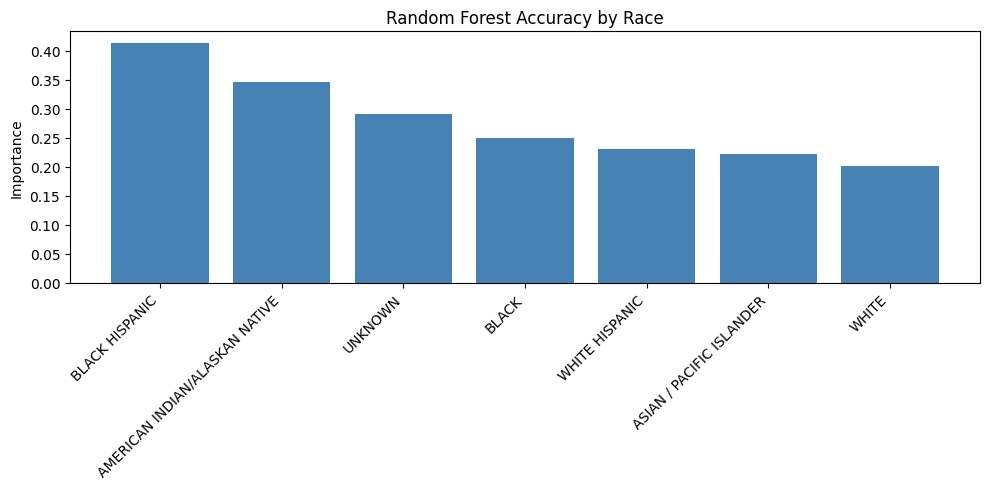

In [ ]:
races = nyar_df['PERP_RACE'].unique()
race_accuracies = []

for race in races:
    # Use y_test.index to get the correct indices for nyar_df
    mask = nyar_df.loc[y_test.index, 'PERP_RACE'] == race
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_tuned[mask])
        race_accuracies.append({'Race': race, 'Accuracy': acc})

race_df = pd.DataFrame(race_accuracies).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(race_df['Race'], race_df['Accuracy'], color='steelblue')
plt.title('Random Forest Accuracy by Race')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
race_df

,Race,Accuracy
4,BLACK HISPANIC,0.412783
6,AMERICAN INDIAN/ALASKAN NATIVE,0.346278
5,UNKNOWN,0.290801
0,BLACK,0.248909
1,WHITE HISPANIC,0.230885
2,ASIAN / PACIFIC ISLANDER,0.222732
3,WHITE,0.200721


In [ ]:
race_balanced_accuracies = []

for race in races:
    # Match rows in the test set for this race
    mask = nyar_df.loc[y_test.index, 'PERP_RACE'] == race

    if mask.sum() > 0:
        bal_acc = balanced_accuracy_score(
            y_test[mask],
            y_pred_tuned[mask]
        )

        race_balanced_accuracies.append({
            'Race': race,
            'Balanced Accuracy': bal_acc
        })

race_bal_df = pd.DataFrame(race_balanced_accuracies).sort_values(
    'Balanced Accuracy',
    ascending=False
)

race_balanced_accuracies

[{'Race': 'BLACK', 'Balanced Accuracy': np.float64(0.490371983531365)},
 {'Race': 'WHITE HISPANIC',
  'Balanced Accuracy': np.float64(0.4976994657541891)},
 {'Race': 'ASIAN / PACIFIC ISLANDER',
  'Balanced Accuracy': np.float64(0.4626975951083416)},
 {'Race': 'WHITE', 'Balanced Accuracy': np.float64(0.5153417830975568)},
 {'Race': 'BLACK HISPANIC',
  'Balanced Accuracy': np.float64(0.5021494805948148)},
 {'Race': 'UNKNOWN', 'Balanced Accuracy': np.float64(0.5524855836150329)},
 {'Race': 'AMERICAN INDIAN/ALASKAN NATIVE',
  'Balanced Accuracy': np.float64(0.5618244336569579)}]

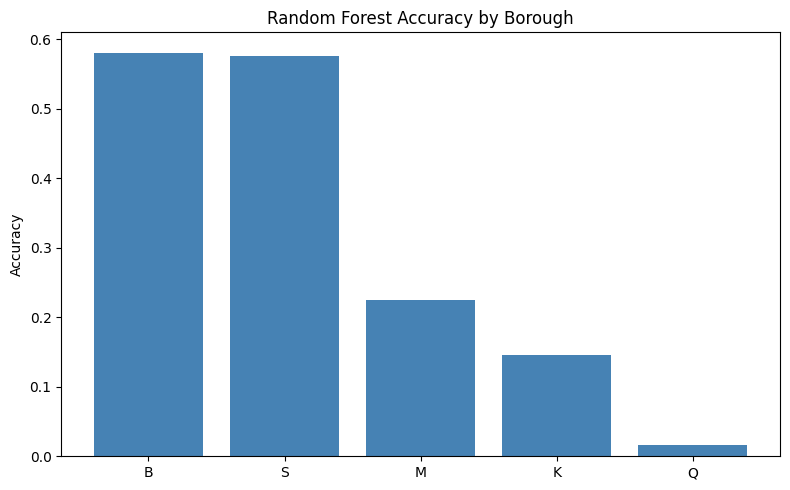

In [ ]:
boros = nyar_df['ARREST_BORO'].unique()
boro_accuracies = []

for boro in boros:
    mask = nyar_df.loc[y_test.index, 'ARREST_BORO'] == boro
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_tuned[mask])
        boro_accuracies.append({'Borough': boro, 'Accuracy': acc})

boro_df = pd.DataFrame(boro_accuracies).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(boro_df['Borough'], boro_df['Accuracy'], color='steelblue')
plt.title('Random Forest Accuracy by Borough')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [ ]:
boro_df

,Borough,Accuracy
2,B,0.581013
4,S,0.575302
1,M,0.225101
0,K,0.146275
3,Q,0.015650


In [ ]:
boro_balanced_acc = []

for boro in boros:
    # Match rows in the test set for this race
    mask = nyar_df.loc[y_test.index, 'ARREST_BORO'] == boro

    if mask.sum() > 0:
        bal_acc = balanced_accuracy_score(
            y_test[mask],
            y_pred_tuned[mask]
        )

        boro_balanced_acc.append({
            'Borough': boro,
            'Balanced Accuracy': bal_acc
        })

boro_bal_df = pd.DataFrame(boro_balanced_acc).sort_values(
    'Balanced Accuracy',
    ascending=False
)

boro_balanced_acc

[{'Borough': 'K', 'Balanced Accuracy': np.float64(0.2975005180622171)},
 {'Borough': 'M', 'Balanced Accuracy': np.float64(0.30714704508375756)},
 {'Borough': 'B', 'Balanced Accuracy': np.float64(0.2611124253867884)},
 {'Borough': 'Q', 'Balanced Accuracy': np.float64(0.25151716865269297)},
 {'Borough': 'S', 'Balanced Accuracy': np.float64(0.26700724766868333)}]

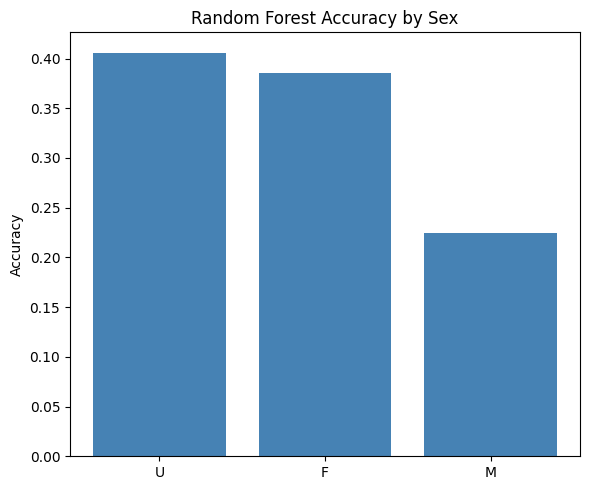

In [ ]:
sexes = nyar_df['PERP_SEX'].unique()
sex_accuracies = []

for sex in sexes:
    mask = nyar_df.loc[y_test.index, 'PERP_SEX'] == sex
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_tuned[mask])
        sex_accuracies.append({'Sex': sex, 'Accuracy': acc})

sex_df = pd.DataFrame(sex_accuracies).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(6, 5))
plt.bar(sex_df['Sex'], sex_df['Accuracy'], color='steelblue')
plt.title('Random Forest Accuracy by Sex')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

In [ ]:
sex_df

,Sex,Accuracy
2,U,0.406015
1,F,0.385154
0,M,0.224929


In [ ]:
sexes = nyar_df['PERP_SEX'].unique()
sex_balanced_accuracies = []

for sex in sexes:
    mask = nyar_df.loc[y_test.index, 'PERP_SEX'] == sex

    if mask.sum() > 0:
        bal_acc = balanced_accuracy_score(
            y_test[mask],
            y_pred_tuned[mask]
        )

        sex_balanced_accuracies.append({
            'Sex': sex,
            'Balanced Accuracy': bal_acc
        })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
sex_balanced_accuracies

[{'Sex': 'M', 'Balanced Accuracy': np.float64(0.49358648185459947)},
 {'Sex': 'F', 'Balanced Accuracy': np.float64(0.5447670386967998)},
 {'Sex': 'U', 'Balanced Accuracy': np.float64(0.21793611793611797)}]

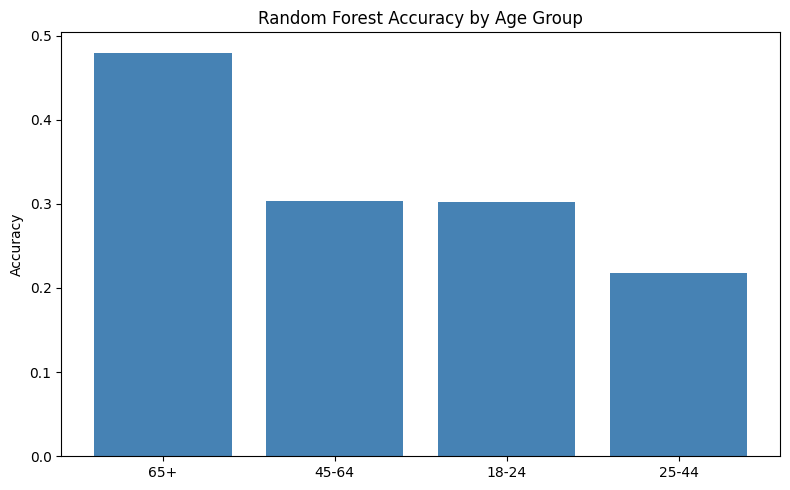

In [ ]:
ages = nyar_df['AGE_GROUP'].unique()
age_accuracies = []

for age in ages:
    mask = nyar_df.loc[y_test.index, 'AGE_GROUP'] == age
    if mask.sum() > 0:
        acc = accuracy_score(y_test[mask], y_pred_tuned[mask])
        age_accuracies.append({'Age Group': age, 'Accuracy': acc})

age_df = pd.DataFrame(age_accuracies).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(age_df['Age Group'], age_df['Accuracy'], color='steelblue')
plt.title('Random Forest Accuracy by Age Group')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# **KNN**

**Let's test accuracy using a KNN model**

In [11]:
# perforimg knn exploration
for k in [1,3,10]:

  model_knn = KNeighborsClassifier(n_neighbors=k).fit(X_train,y_train)

  y_pred = model_knn.predict(X_test)

  print(f"k={k}:", sk.metrics.accuracy_score(y_pred, y_test))

k=1: 0.49388333261793366
k=3: 0.5140039490063099
k=10: 0.5182319611967207


**Our best k, 1, has a base accuracy of ~52%, which is lower than our RFC.**

**Let's select a subset of our dataset and perform cross-validation. We'll randomly sample our data because the amount of calculations will take a long time.**


In [13]:
# selecting random index
idx = np.random.choice(len(X_train), size=100000, replace=False)

# saving sample
X_sample = X_train[idx]
y_sample = y_train.iloc[idx]

In [14]:
# initalizing 3-fold validation
cv = KFold(n_splits=3, shuffle=True, random_state=342)

best_k = None
lowest_error = float("inf")

# loop twenty times
for k in range(1, 21):

    # StandardScaler() used for centering
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # calculating error rate
    scores = cross_val_score(pipeline, X_sample, y_sample, cv=cv, scoring='accuracy',
        n_jobs=-1
    )

    mean_error = 1 - scores.mean()

    if mean_error < lowest_error:
        lowest_error = mean_error
        best_k = k

# saving model using best k
best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

# fitting best model
best_model.fit(X_sample, y_sample)

print("Best k:", best_k)
print("Best CV error rate:", lowest_error)

Best k: 19
Best CV error rate: 0.463919909793686


In [15]:
best_model = KNeighborsClassifier(n_neighbors=19).fit(X_train,y_train)

In [16]:
y_pred = best_model.predict(X_test)
sk.metrics.accuracy_score(y_pred, y_test)

0.544297549040649

**Our best post-cv k is 19. It has a base accuracy of again ~55%, which is higher than our RFC base accuracy of 0.24.**

**We cannot compute feature importance for KNN, but let's take a look at accuracy by group and the confusion matrix to see how our model performs across offense levels.**

In [17]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
9    0.000000
F    0.226730
M    0.787213
V    0.000000
Name: correct, dtype: float64


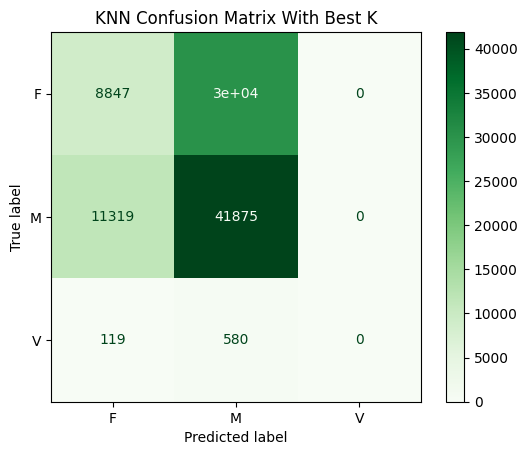

In [18]:
# constructing matrix
cm = confusion_matrix(y_test, y_pred, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])

# plotting
disp.plot(cmap='Greens')
plt.title('KNN Confusion Matrix With Best K')
plt.show()

**We see KNN is even worse at predicting the least-common class, which makes sense given how KNN makes predictions. There are not a signifigant amount of neighbors who are also accused of a violation.**

In [19]:
# Re-extract borough_data from the cleaned dataframe so row counts match
borough_cols = ['IS_QUEENS', 'IS_BRONX', 'IS_MANH', 'IS_BROOK', 'IS_STATEN']
borough_data_knn = nyar_df.loc[valid_indices, borough_cols].reset_index(drop=True)

# Rebuild X and y with reset index so everything aligns
X_knn = pd.DataFrame(X_scaled, columns=X.columns)
y_knn = y.reset_index(drop=True)

# train/test split
X_train_knn, X_test_knn, y_train_knn, y_test_knn, b_train_knn, b_test_knn = train_test_split(
    X_knn, y_knn, borough_data_knn, test_size=0.2, random_state=42
)

# fit model
knn_boro_model = KNeighborsClassifier(n_neighbors=19).fit(X_train_knn, y_train_knn)

# filter test set by borough
queens_test    = b_test_knn['IS_QUEENS']  == 1
bronx_test     = b_test_knn['IS_BRONX']   == 1
manhattan_test = b_test_knn['IS_MANH']   == 1
brooklyn_test  = b_test_knn['IS_BROOK']  == 1
staten_test    = b_test_knn['IS_STATEN'] == 1

X_test_queens    = X_test_knn[queens_test];    y_test_queens    = y_test_knn[queens_test]
X_test_bronx     = X_test_knn[bronx_test];     y_test_bronx     = y_test_knn[bronx_test]
X_test_manhattan = X_test_knn[manhattan_test]; y_test_manhattan = y_test_knn[manhattan_test]
X_test_brooklyn  = X_test_knn[brooklyn_test];  y_test_brooklyn  = y_test_knn[brooklyn_test]
X_test_staten    = X_test_knn[staten_test];    y_test_staten    = y_test_knn[staten_test]

print('Queens accuracy:',        accuracy_score(y_test_queens,    knn_boro_model.predict(X_test_queens)))
print('Bronx accuracy:',         accuracy_score(y_test_bronx,     knn_boro_model.predict(X_test_bronx)))
print('Manhattan accuracy:',     accuracy_score(y_test_manhattan, knn_boro_model.predict(X_test_manhattan)))
print('Brooklyn accuracy:',      accuracy_score(y_test_brooklyn,  knn_boro_model.predict(X_test_brooklyn)))
print('Staten Island accuracy:', accuracy_score(y_test_staten,    knn_boro_model.predict(X_test_staten)))

Queens accuracy: 0.5453100158982512
Bronx accuracy: 0.5468801352176158
Manhattan accuracy: 0.5527978544479295
Brooklyn accuracy: 0.53067496595993
Staten Island accuracy: 0.5659354202612769


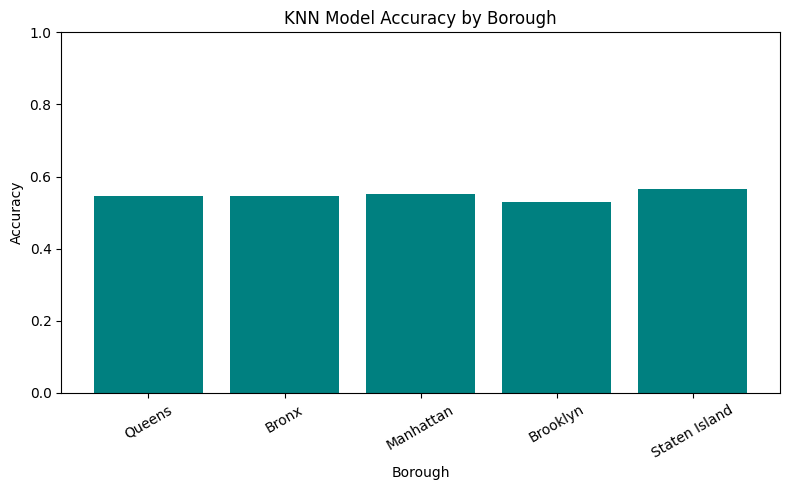

In [20]:
# KNN Accuracy by Borough
knn_boro_accuracies = {
    'Queens':        accuracy_score(y_test_queens,    knn_boro_model.predict(X_test_queens)),
    'Bronx':         accuracy_score(y_test_bronx,     knn_boro_model.predict(X_test_bronx)),
    'Manhattan':     accuracy_score(y_test_manhattan, knn_boro_model.predict(X_test_manhattan)),
    'Brooklyn':      accuracy_score(y_test_brooklyn,  knn_boro_model.predict(X_test_brooklyn)),
    'Staten Island': accuracy_score(y_test_staten,    knn_boro_model.predict(X_test_staten))
}

plt.figure(figsize=(8, 5))
plt.bar(knn_boro_accuracies.keys(), knn_boro_accuracies.values(), color='teal')
plt.title('KNN Model Accuracy by Borough')
plt.ylabel('Accuracy')
plt.xlabel('Borough')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('knn_borough_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

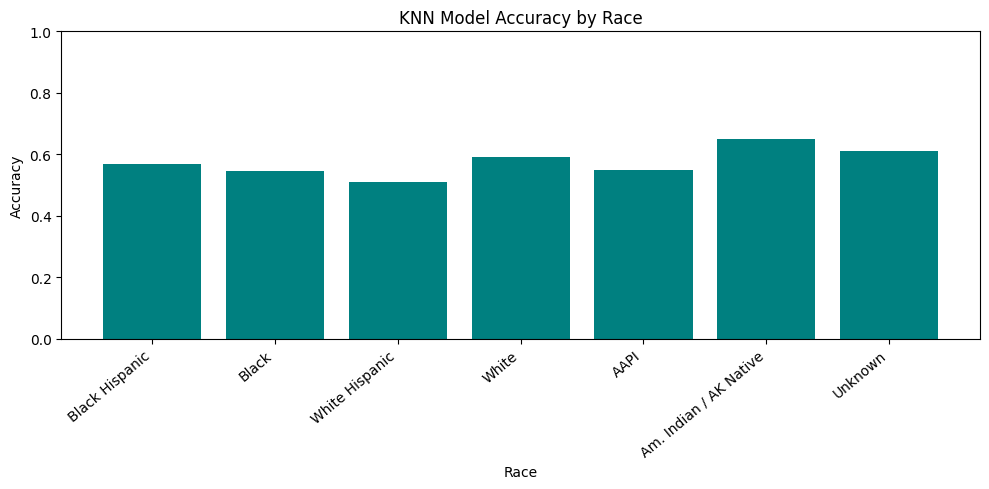

In [21]:
# KNN Accuracy by Race
race_data_knn = nyar_df.loc[valid_indices, race_cols].reset_index(drop=True)

X_train_knn, X_test_knn, y_train_knn, y_test_knn, r_train_knn, r_test_knn = train_test_split(
    X_knn, y_knn, race_data_knn, test_size=0.2, random_state=42
)

knn_race_model = KNeighborsClassifier(n_neighbors=19).fit(X_train_knn, y_train_knn)

black_hisp_test  = r_test_knn['IS_BLACK_HISPANIC'] == 1
black_test       = r_test_knn['IS_BLACK']          == 1
white_hisp_test  = r_test_knn['IS_WHITE_HISPANIC'] == 1
white_test       = r_test_knn['IS_WHITE']          == 1
aapi_test        = r_test_knn['IS_AAPI']           == 1
am_in_ak_na_test = r_test_knn['IS_AM_IN_AK_NA']   == 1
unknown_test     = r_test_knn['RACE_IS_UNKNOWN']   == 1

X_test_black_hisp  = X_test_knn[black_hisp_test];  y_test_black_hisp  = y_test_knn[black_hisp_test]
X_test_black       = X_test_knn[black_test];        y_test_black       = y_test_knn[black_test]
X_test_white_hisp  = X_test_knn[white_hisp_test];  y_test_white_hisp  = y_test_knn[white_hisp_test]
X_test_white       = X_test_knn[white_test];        y_test_white       = y_test_knn[white_test]
X_test_aapi        = X_test_knn[aapi_test];         y_test_aapi        = y_test_knn[aapi_test]
X_test_am_in_ak_na = X_test_knn[am_in_ak_na_test]; y_test_am_in_ak_na = y_test_knn[am_in_ak_na_test]
X_test_unknown     = X_test_knn[unknown_test];      y_test_unknown     = y_test_knn[unknown_test]

knn_race_accuracies = {
    'Black Hispanic':         accuracy_score(y_test_black_hisp,  knn_race_model.predict(X_test_black_hisp)),
    'Black':                  accuracy_score(y_test_black,        knn_race_model.predict(X_test_black)),
    'White Hispanic':         accuracy_score(y_test_white_hisp,  knn_race_model.predict(X_test_white_hisp)),
    'White':                  accuracy_score(y_test_white,        knn_race_model.predict(X_test_white)),
    'AAPI':                   accuracy_score(y_test_aapi,         knn_race_model.predict(X_test_aapi)),
    'Am. Indian / AK Native': accuracy_score(y_test_am_in_ak_na, knn_race_model.predict(X_test_am_in_ak_na)),
    'Unknown':                accuracy_score(y_test_unknown,      knn_race_model.predict(X_test_unknown))
}

plt.figure(figsize=(10, 5))
plt.bar(knn_race_accuracies.keys(), knn_race_accuracies.values(), color='teal')
plt.title('KNN Model Accuracy by Race')
plt.ylabel('Accuracy')
plt.xlabel('Race')
plt.ylim(0, 1)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('knn_race_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

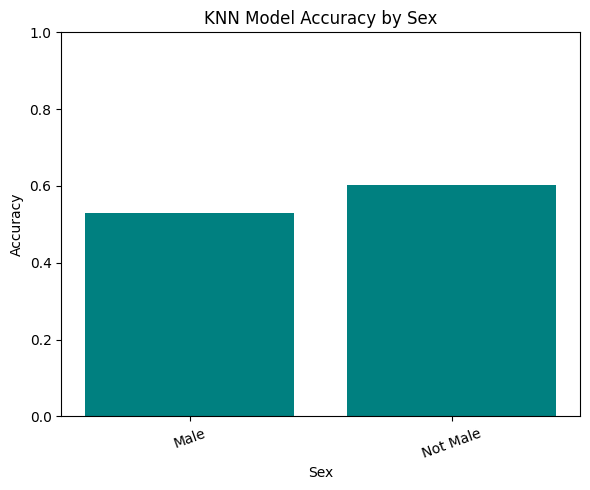

In [22]:
# KNN Accuracy by Sex
sex_data_knn = nyar_df.loc[valid_indices, sex_cols].reset_index(drop=True)

X_train_knn, X_test_knn, y_train_knn, y_test_knn, s_train_knn, s_test_knn = train_test_split(
    X_knn, y_knn, sex_data_knn, test_size=0.2, random_state=42
)

knn_sex_model = KNeighborsClassifier(n_neighbors=19).fit(X_train_knn, y_train_knn)

male_test     = s_test_knn['IS_MALE'] == 1
not_male_test = s_test_knn['IS_MALE'] == 0

X_test_male     = X_test_knn[male_test];     y_test_male     = y_test_knn[male_test]
X_test_not_male = X_test_knn[not_male_test]; y_test_not_male = y_test_knn[not_male_test]

knn_sex_accuracies = {
    'Male':     accuracy_score(y_test_male,     knn_sex_model.predict(X_test_male)),
    'Not Male': accuracy_score(y_test_not_male, knn_sex_model.predict(X_test_not_male))
}

plt.figure(figsize=(6, 5))
plt.bar(knn_sex_accuracies.keys(), knn_sex_accuracies.values(), color='teal')
plt.title('KNN Model Accuracy by Sex')
plt.ylabel('Accuracy')
plt.xlabel('Sex')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('knn_sex_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
print(knn_race_accuracies)

{'Black Hispanic': 0.5672109873472477, 'Black': 0.5467875659502547, 'White Hispanic': 0.5093993393956694, 'White': 0.5908126458731169, 'AAPI': 0.5478377344048986, 'Am. Indian / AK Native': 0.6504854368932039, 'Unknown': 0.6112759643916914}


In [58]:
print(knn_sex_accuracies)

{'Male': 0.5309467697128487, 'Not Male': 0.6031331592689295}


# **Logisitic Regression**

In [12]:
# setting logistic regression as our model choice
algo = sk.linear_model.LogisticRegression(max_iter=5000)
model = algo.fit(X_train, y_train)

In [23]:
y_pred = model.predict(X_test)

# basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.573453663561832
Balanced Accuracy: 0.2543319454911682


**The model accurately predicts offense level ~57% of the time, but only ~25% when measuring balanced accuracy. It performs similarly to our RFC when testing base accuracy and balanced accuracy.**

**Let's look at the confusion matrix.**

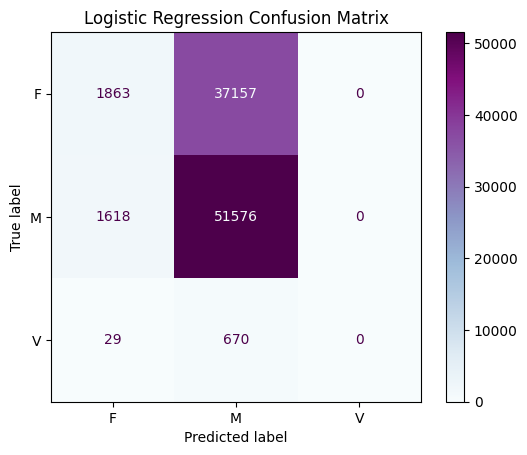

In [24]:
cm = confusion_matrix(y_test, y_pred, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])
disp.plot(cmap='BuPu')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

**To better illustrate performance, we can also oberse accuracy by offense level as proportions.**

In [25]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
9    0.000000
F    0.047745
M    0.969583
V    0.000000
Name: correct, dtype: float64


**OBESERVING ACCURACY BY LOCATION**

**Now we seperate the test set by borough, and use the model to predict base accuracy in each borough.**

In [26]:
# train/test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr, b_train, b_test = train_test_split(
    X_scaled, y, borough_data, test_size=0.2, random_state=42
)

# training model
algo = sk.linear_model.LogisticRegression(max_iter=5000)
model = algo.fit(X_train_lr, y_train_lr)

# filtering test set by borough
queens_test = b_test['IS_QUEENS'] == 1
bronx_test = b_test['IS_BRONX'] == 1
manhattan_test = b_test['IS_MANH'] == 1
brooklyn_test = b_test['IS_BROOK'] == 1
staten_test = b_test['IS_STATEN'] == 1

# seperating X and y
X_test_queens = X_test_lr[queens_test]
y_test_queens = y_test_lr[queens_test]

X_test_bronx = X_test_lr[bronx_test]
y_test_bronx = y_test_lr[bronx_test]

X_test_manhattan = X_test_lr[manhattan_test]
y_test_manhattan = y_test_lr[manhattan_test]

X_test_brooklyn = X_test_lr[brooklyn_test]
y_test_brooklyn = y_test_lr[brooklyn_test]

X_test_staten = X_test_lr[staten_test]
y_test_staten = y_test_lr[staten_test]

# predicting and printing base accuracy
print("Queens accuracy:", accuracy_score(y_test_queens, model.predict(X_test_queens)))
print("Bronx accuracy:", accuracy_score(y_test_bronx, model.predict(X_test_bronx)))
print("Manhattan accuracy:", accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)))
print("Brooklyn accuracy:", accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)))
print("Staten Island accuracy:", accuracy_score(y_test_staten, model.predict(X_test_staten)))

Queens accuracy: 0.5613573131955485
Bronx accuracy: 0.5915301187849195
Manhattan accuracy: 0.585708441292786
Brooklyn accuracy: 0.5512157167866174
Staten Island accuracy: 0.6130145427655903


**The model performs best for arrests in the Bronx and Manhatten, then Queens and Staten Island. The worst performing borough was Brooklyn. Let's plot the results.**

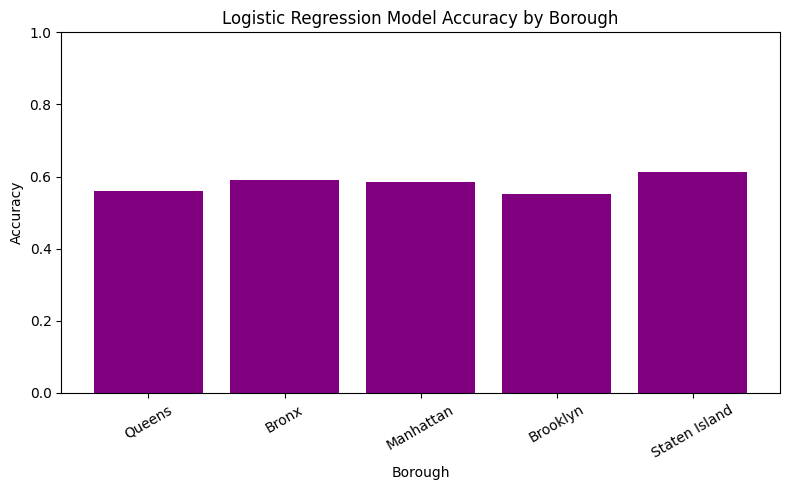

In [27]:
# storing accuracies to plot
accuracies = {
    "Queens": accuracy_score(y_test_queens, model.predict(X_test_queens)),
    "Bronx": accuracy_score(y_test_bronx, model.predict(X_test_bronx)),
    "Manhattan": accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)),
    "Brooklyn": accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)),
    "Staten Island": accuracy_score(y_test_staten, model.predict(X_test_staten))
}

# plotting
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color='purple')
plt.title("Logistic Regression Model Accuracy by Borough")
plt.ylabel("Accuracy")
plt.xlabel("Borough")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()

# saving
plt.savefig("borough_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

**Let's observe balanced accuracy across borough as well.**

In [28]:
# predicting and printing balanced accuracy
print("Queens Balanced balanced accuracy:", balanced_accuracy_score(y_test_queens, model.predict(X_test_queens)))
print("Bronx balanced accuracy:", balanced_accuracy_score(y_test_bronx, model.predict(X_test_bronx)))
print("Manhattan balanced accuracy:", balanced_accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)))
print("Brooklyn balaned accuracy:", balanced_accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)))
print("Staten Island balanced accuracy:", balanced_accuracy_score(y_test_staten, model.predict(X_test_staten)))

Queens Balanced balanced accuracy: 0.2548511870910644
Bronx balanced accuracy: 0.25
Manhattan balanced accuracy: 0.25
Brooklyn balaned accuracy: 0.2588138728682102
Staten Island balanced accuracy: 0.25


**An interesting phenomenon occured. Brooklyn's balanced accuracy is now the highest, and the Bronx and Manhatten, our two high performers in the base accuracy metric, have the worst balanced accuracy. The 0.333 proportion is interesting too, especially as it repeats across Bronx, Manhattan, and Staten Island.**

**OBESERVING ACCURACY BY RACE**

In [29]:
# Train/Test Split
X_train_lr, X_test_lr, y_train_lr, y_test_lr, r_train, r_test = train_test_split(
    X_scaled, y, race_data, test_size=0.2, random_state=42
)

# training model
algo = sk.linear_model.LogisticRegression(max_iter=5000)
model = algo.fit(X_train_lr, y_train_lr)

# filtering test set by race
black_hisp_test = r_test['IS_BLACK_HISPANIC'] == 1
black_test = r_test['IS_BLACK'] == 1
white_hisp_test = r_test['IS_WHITE_HISPANIC'] == 1
white_test = r_test['IS_WHITE'] == 1
aapi_test = r_test['IS_AAPI'] == 1
am_in_ak_na_test = r_test['IS_AM_IN_AK_NA'] == 1
unknown_test = r_test['RACE_IS_UNKNOWN'] == 1

# separating X and y
X_test_black_hisp = X_test_lr[black_hisp_test]
y_test_black_hisp = y_test_lr[black_hisp_test]

X_test_black = X_test_lr[black_test]
y_test_black = y_test_lr[black_test]

X_test_white_hisp = X_test_lr[white_hisp_test]
y_test_white_hisp = y_test_lr[white_hisp_test]

X_test_white = X_test_lr[white_test]
y_test_white = y_test_lr[white_test]

X_test_aapi = X_test_lr[aapi_test]
y_test_aapi = y_test_lr[aapi_test]

X_test_am_in_ak_na = X_test_lr[am_in_ak_na_test]
y_test_am_in_ak_na = y_test_lr[am_in_ak_na_test]

X_test_unknown = X_test_lr[unknown_test]
y_test_unknown = y_test_lr[unknown_test]

# predicting and printing base accuracy
print("Black Hispanic accuracy:", accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)))
print("Black accuracy:", accuracy_score(y_test_black, model.predict(X_test_black)))
print("White Hispanic accuracy:", accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)))
print("White accuracy:", accuracy_score(y_test_white, model.predict(X_test_white)))
print("AAPI accuracy:", accuracy_score(y_test_aapi, model.predict(X_test_aapi)))
print("American Indian / Alaska Native accuracy:", accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)))
print("Unknown race accuracy:", accuracy_score(y_test_unknown, model.predict(X_test_unknown)))

Black Hispanic accuracy: 0.5772683032334811
Black accuracy: 0.5512870292122514
White Hispanic accuracy: 0.5916486563634139
White accuracy: 0.6123488224061108
AAPI accuracy: 0.5845771144278606
American Indian / Alaska Native accuracy: 0.6472491909385113
Unknown race accuracy: 0.6350148367952523


**The model performs best with American Indian and Alaskan Natives, which we predict is due to a small presence in the dataset. The model performs better with persons arrested who were White, White Hispanic, or AAPI, and worse with those who are Black or Black Hispanic. If we plot:**

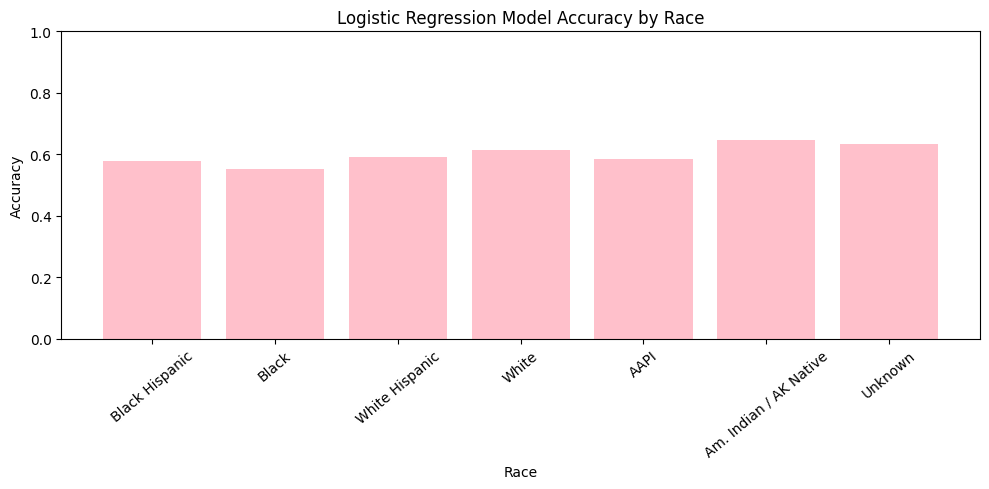

In [30]:
# storing accuracies to plot
race_accuracies = {
    "Black Hispanic": accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)),
    "Black": accuracy_score(y_test_black, model.predict(X_test_black)),
    "White Hispanic": accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)),
    "White": accuracy_score(y_test_white, model.predict(X_test_white)),
    "AAPI": accuracy_score(y_test_aapi, model.predict(X_test_aapi)),
    "Am. Indian / AK Native": accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)),
    "Unknown": accuracy_score(y_test_unknown, model.predict(X_test_unknown))
}

# plotting
plt.figure(figsize=(10,5))
plt.bar(race_accuracies.keys(), race_accuracies.values(), color='pink')
plt.title("Logistic Regression Model Accuracy by Race")
plt.ylabel("Accuracy")
plt.xlabel("Race")
plt.ylim(0, 1)
plt.xticks(rotation=40)
plt.tight_layout()

# saving
plt.savefig("race_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

**Let's observe balanced accuracy across race as well.**

In [31]:
# predicting and printing balanced accuracy
print("Black Hispanic balanced accuracy:", balanced_accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)))
print("Black balanced accuracy:", balanced_accuracy_score(y_test_black, model.predict(X_test_black)))
print("White Hispanic balanced accuracy:", balanced_accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)))
print("White balanced accuracy:", balanced_accuracy_score(y_test_white, model.predict(X_test_white)))
print("AAPI balanced accuracy:", balanced_accuracy_score(y_test_aapi, model.predict(X_test_aapi)))
print("American Indian / Alaska Native balanced accuracy:", balanced_accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)))
print("Unknown race balanced accuracy:", balanced_accuracy_score(y_test_unknown, model.predict(X_test_unknown)))

Black Hispanic balanced accuracy: 0.25259662580997544
Black balanced accuracy: 0.25666600234208037
White Hispanic balanced accuracy: 0.25
White balanced accuracy: 0.25
AAPI balanced accuracy: 0.25
American Indian / Alaska Native balanced accuracy: 0.25
Unknown race balanced accuracy: 0.25


**Here we see the balanced accuracy for those arrested who were Black or Black Hispanic decrease less than those in other racial groups. Another interesting result worth digging into.**

**OBESERVING ACCURACY BY SEX**

In [32]:
# Train/Test Split
X_train_lr, X_test_lr, y_train_lr, y_test_lr, s_train, s_test = train_test_split(
    X_scaled, y, sex_data, test_size=0.2, random_state=42
)

# training model
algo = sk.linear_model.LogisticRegression(max_iter=5000)
model = algo.fit(X_train_lr, y_train_lr)

# filtering test set by race
male_test = s_test['IS_MALE'] == 1
not_male_test = s_test['IS_MALE'] == 0

# separating X and y
X_test_male = X_test_lr[male_test]
y_test_male = y_test_lr[male_test]

X_test_not_male = X_test_lr[not_male_test]
y_test_not_male = y_test_lr[not_male_test]

# predicting and printing base accuracy
print("Male accuracy:", accuracy_score(y_test_male, model.predict(X_test_male)))
print("Not Male accuracy:", accuracy_score(y_test_not_male, model.predict(X_test_not_male)))
print('\n')

# predicting and printing balanced accuracy
print("Male balanced accuracy:", balanced_accuracy_score(y_test_male, model.predict(X_test_male)))
print("Not Male balanced accuracy:", balanced_accuracy_score(y_test_not_male, model.predict(X_test_not_male)))

Male accuracy: 0.5623740997722275
Not Male accuracy: 0.6222802436901653


Male balanced accuracy: 0.25474252153420845
Not Male balanced accuracy: 0.25


**Another opposite effect occured. Non-male arrest predictions had a higher base accuracy, but a bigger decrease into an almost even balanced accuracy. Let's plot base accuracy, like our other categories above.**

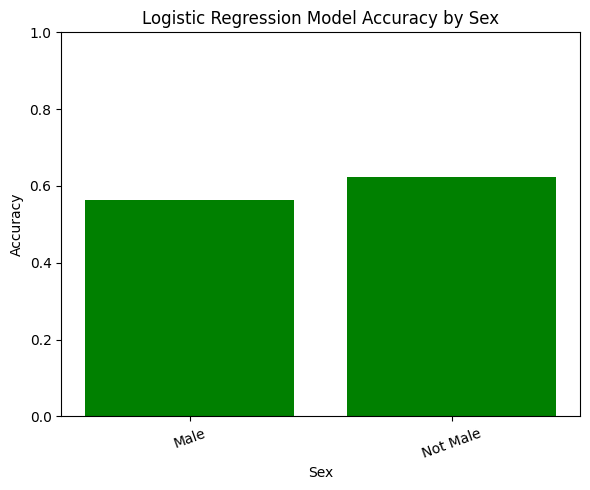

In [33]:
# storing accuracies to plot
sex_accuracies = {
    "Male": accuracy_score(y_test_male, model.predict(X_test_male)),
    "Not Male": accuracy_score(y_test_not_male, model.predict(X_test_not_male))
}

# plotting
plt.figure(figsize=(6,5))
plt.bar(sex_accuracies.keys(), sex_accuracies.values(), color='green')
plt.title("Logistic Regression Model Accuracy by Sex")
plt.ylabel("Accuracy")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

# saving
plt.savefig("sex_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

# **Neural Nets**

In [34]:
# establishing neural network features
clf = MLPClassifier(
    hidden_layer_sizes=(62, 34),
    solver='adam',
    alpha=1e-4,
    max_iter=200,
    random_state=1
)

model = clf.fit(X_train, y_train)

**Let's see our model accuracy using our Multi-layer Perceptron (MLP) algorithm:**

In [35]:
# making predictions
y_pred = model.predict(X_test)

# basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.5754818216937803
Balanced Accuracy: 0.25818388994284475


**And our associated confusion matrix:**

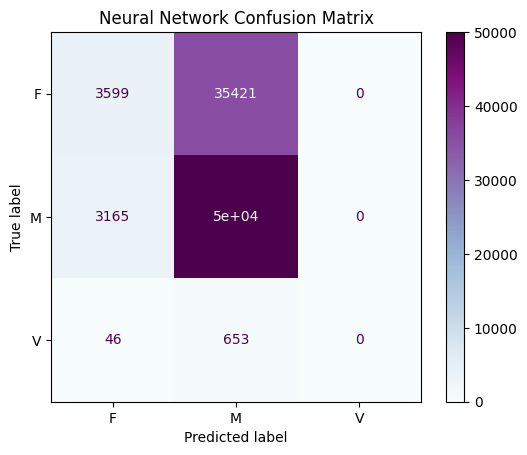

In [36]:
cm = confusion_matrix(y_test, y_pred, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])
disp.plot(cmap='BuPu')
plt.title('Neural Network Confusion Matrix')
plt.show()

**We still observe low accuracies and similar issues with our confusion matrix.**

In [37]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
9    0.000000
F    0.092235
M    0.940501
V    0.000000
Name: correct, dtype: float64


**We see an extremely high accuracy for misdemeanors, which makes increasing sense given our data points, but this model is the most accurate at predicting that dominant class.**

**OBESERVING ACCURACY BY LOCATION**

In [38]:
# train/test split
# Ensure borough_data is aligned with X_scaled and y
borough_data_aligned = borough_data.loc[valid_indices]

X_train_lr, X_test_lr, y_train_lr, y_test_lr, b_train, b_test = train_test_split(
    X_scaled, y, borough_data_aligned, test_size=0.2, random_state=42
)

# training model
model = clf.fit(X_train_lr, y_train_lr)

# filtering test set by borough
queens_test = b_test['IS_QUEENS'] == 1
bronx_test = b_test['IS_BRONX'] == 1
manhattan_test = b_test['IS_MANH'] == 1
brooklyn_test = b_test['IS_BROOK'] == 1
staten_test = b_test['IS_STATEN'] == 1

# seperating X and y
X_test_queens = X_test_lr[queens_test]
y_test_queens = y_test_lr[queens_test]

X_test_bronx = X_test_lr[bronx_test]
y_test_bronx = y_test_lr[bronx_test]

X_test_manhattan = X_test_lr[manhattan_test]
y_test_manhattan = y_test_lr[manhattan_test]

X_test_brooklyn = X_test_lr[brooklyn_test]
y_test_brooklyn = y_test_lr[brooklyn_test]

X_test_staten = X_test_lr[staten_test]
y_test_staten = y_test_lr[staten_test]

# predicting and printing base accuracy
print("Queens accuracy:", accuracy_score(y_test_queens, model.predict(X_test_queens)))
print("Bronx accuracy:", accuracy_score(y_test_bronx, model.predict(X_test_bronx)))
print("Manhattan accuracy:", accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)))
print("Brooklyn accuracy:", accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)))
print("Staten Island accuracy:", accuracy_score(y_test_staten, model.predict(X_test_staten)))

Queens accuracy: 0.5611089030206677
Bronx accuracy: 0.5931733884219916
Manhattan accuracy: 0.5929360425473885
Brooklyn accuracy: 0.5512157167866174
Staten Island accuracy: 0.6130145427655903


**Observing similar proportions to that of the logistic regression model, with the Bronx, Manhattan, and Staten Island with the highest accuracy, and Brooklyn at the bottom.**

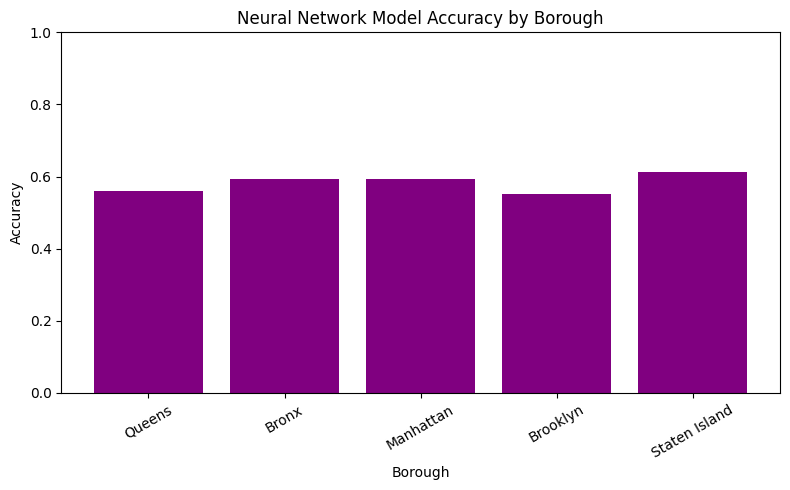

In [39]:
# storing accuracies to plot
accuracies = {
    "Queens": accuracy_score(y_test_queens, model.predict(X_test_queens)),
    "Bronx": accuracy_score(y_test_bronx, model.predict(X_test_bronx)),
    "Manhattan": accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)),
    "Brooklyn": accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)),
    "Staten Island": accuracy_score(y_test_staten, model.predict(X_test_staten))
}

# plotting
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color='purple')
plt.title("Neural Network Model Accuracy by Borough")
plt.ylabel("Accuracy")
plt.xlabel("Borough")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()

# saving
plt.savefig("borough_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

In [40]:
# predicting and printing balanced accuracy
print("Queens Balanced balanced accuracy:", balanced_accuracy_score(y_test_queens, model.predict(X_test_queens)))
print("Bronx balanced accuracy:", balanced_accuracy_score(y_test_bronx, model.predict(X_test_bronx)))
print("Manhattan balanced accuracy:", balanced_accuracy_score(y_test_manhattan, model.predict(X_test_manhattan)))
print("Brooklyn balanced accuracy:", balanced_accuracy_score(y_test_brooklyn, model.predict(X_test_brooklyn)))
print("Staten Island balanced accuracy:", balanced_accuracy_score(y_test_staten, model.predict(X_test_staten)))

Queens Balanced balanced accuracy: 0.25676933417960496
Bronx balanced accuracy: 0.2576604201274496
Manhattan balanced accuracy: 0.259151340032283
Brooklyn balanced accuracy: 0.2588178483462337
Staten Island balanced accuracy: 0.25


**An interesting result when looking at balanced accuracies. They all are incredibly similar.**

**OBESERVING ACCURACY BY RACE**

In [41]:
# Train/Test Split
race_data_aligned = race_data.loc[valid_indices]
X_train_lr, X_test_lr, y_train_lr, y_test_lr, r_train, r_test = train_test_split(
    X_scaled, y, race_data_aligned, test_size=0.2, random_state=42
)

# training model
model = clf.fit(X_train_lr, y_train_lr)

# filtering test set by race
black_hisp_test = r_test['IS_BLACK_HISPANIC'] == 1
black_test = r_test['IS_BLACK'] == 1
white_hisp_test = r_test['IS_WHITE_HISPANIC'] == 1
white_test = r_test['IS_WHITE'] == 1
aapi_test = r_test['IS_AAPI'] == 1
am_in_ak_na_test = r_test['IS_AM_IN_AK_NA'] == 1
unknown_test = r_test['RACE_IS_UNKNOWN'] == 1

# separating X and y
X_test_black_hisp = X_test_lr[black_hisp_test]
y_test_black_hisp = y_test_lr[black_hisp_test]

X_test_black = X_test_lr[black_test]
y_test_black = y_test_lr[black_test]

X_test_white_hisp = X_test_lr[white_hisp_test]
y_test_white_hisp = y_test_lr[white_hisp_test]

X_test_white = X_test_lr[white_test]
y_test_white = y_test_lr[white_test]

X_test_aapi = X_test_lr[aapi_test]
y_test_aapi = y_test_lr[aapi_test]

X_test_am_in_ak_na = X_test_lr[am_in_ak_na_test]
y_test_am_in_ak_na = y_test_lr[am_in_ak_na_test]

X_test_unknown = X_test_lr[unknown_test]
y_test_unknown = y_test_lr[unknown_test]

# predicting and printing base accuracy
print("Black Hispanic accuracy:", accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)))
print("Black accuracy:", accuracy_score(y_test_black, model.predict(X_test_black)))
print("White Hispanic accuracy:", accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)))
print("White accuracy:", accuracy_score(y_test_white, model.predict(X_test_white)))
print("AAPI accuracy:", accuracy_score(y_test_aapi, model.predict(X_test_aapi)))
print("American Indian / Alaska Native accuracy:", accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)))
print("Unknown race accuracy:", accuracy_score(y_test_unknown, model.predict(X_test_unknown)))

Black Hispanic accuracy: 0.5782415918676328
Black accuracy: 0.5557179727291415
White Hispanic accuracy: 0.5916486563634139
White accuracy: 0.6123488224061108
AAPI accuracy: 0.5818982013011864
American Indian / Alaska Native accuracy: 0.6472491909385113
Unknown race accuracy: 0.6350148367952523


**Similar results as our logistic regression model.**

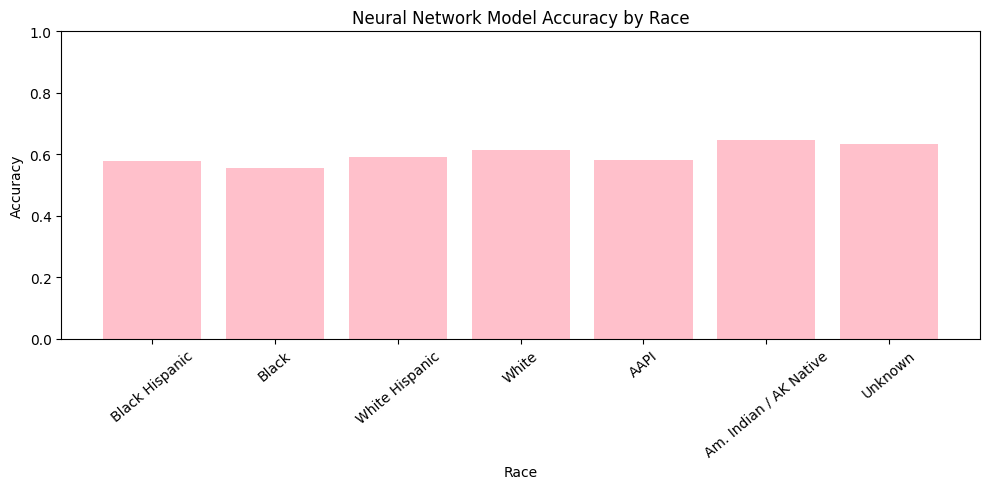

In [42]:
# storing accuracies to plot
race_accuracies = {
    "Black Hispanic": accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)),
    "Black": accuracy_score(y_test_black, model.predict(X_test_black)),
    "White Hispanic": accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)),
    "White": accuracy_score(y_test_white, model.predict(X_test_white)),
    "AAPI": accuracy_score(y_test_aapi, model.predict(X_test_aapi)),
    "Am. Indian / AK Native": accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)),
    "Unknown": accuracy_score(y_test_unknown, model.predict(X_test_unknown))
}

# plotting
plt.figure(figsize=(10,5))
plt.bar(race_accuracies.keys(), race_accuracies.values(), color='pink')
plt.title("Neural Network Model Accuracy by Race")
plt.ylabel("Accuracy")
plt.xlabel("Race")
plt.ylim(0, 1)
plt.xticks(rotation=40)
plt.tight_layout()

# saving
plt.savefig("race_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

In [43]:
# predicting and printing balanced accuracy
print("Black Hispanic balanced accuracy:", balanced_accuracy_score(y_test_black_hisp, model.predict(X_test_black_hisp)))
print("Black balanced accuracy:", balanced_accuracy_score(y_test_black, model.predict(X_test_black)))
print("White Hispanic balanced accuracy:", balanced_accuracy_score(y_test_white_hisp, model.predict(X_test_white_hisp)))
print("White balanced accuracy:", balanced_accuracy_score(y_test_white, model.predict(X_test_white)))
print("AAPI balanced accuracy:", balanced_accuracy_score(y_test_aapi, model.predict(X_test_aapi)))
print("American Indian / Alaska Native balanced accuracy:", balanced_accuracy_score(y_test_am_in_ak_na, model.predict(X_test_am_in_ak_na)))
print("Unknown race balanced accuracy:", balanced_accuracy_score(y_test_unknown, model.predict(X_test_unknown)))

Black Hispanic balanced accuracy: 0.25532778421997365
Black balanced accuracy: 0.26215075488251677
White Hispanic balanced accuracy: 0.25
White balanced accuracy: 0.25
AAPI balanced accuracy: 0.2547369167275406
American Indian / Alaska Native balanced accuracy: 0.25117718446601944
Unknown race balanced accuracy: 0.25


**This model does appear to have a slightly higher balanced accuracy rate for certain groups. The accuracies are still low, however, and do suggest we lack an appopriate amount of features, or the right features, to make quality predictions.**

**OBESERVING ACCURACY BY SEX**

In [44]:
# Train/Test Split
sex_data_aligned = sex_data.loc[valid_indices]
X_train_lr, X_test_lr, y_train_lr, y_test_lr, s_train, s_test = train_test_split(
    X_scaled, y, sex_data_aligned, test_size=0.2, random_state=42
)

# training model
model = clf.fit(X_train_lr, y_train_lr)

# filtering test set by race
male_test = s_test['IS_MALE'] == 1
not_male_test = s_test['IS_MALE'] == 0

# separating X and y
X_test_male = X_test_lr[male_test]
y_test_male = y_test_lr[male_test]

X_test_not_male = X_test_lr[not_male_test]
y_test_not_male = y_test_lr[not_male_test]

# predicting and printing base accuracy
print("Male accuracy:", accuracy_score(y_test_male, model.predict(X_test_male)))
print("Not Male accuracy:", accuracy_score(y_test_not_male, model.predict(X_test_not_male)))
print('\n')

# predicting and printing balanced accuracy
print("Male balanced accuracy:", balanced_accuracy_score(y_test_male, model.predict(X_test_male)))
print("Not Male balanced accuracy:", balanced_accuracy_score(y_test_not_male, model.predict(X_test_not_male)))

Male accuracy: 0.564862480744671
Not Male accuracy: 0.6222802436901653


Male balanced accuracy: 0.2589304111296468
Not Male balanced accuracy: 0.25


**Above we observe that the MLP model is slightly better than our logistic regression model when observing balanced accuracy. The logisitc regression model had a poorer balanced accuracy score for those who were male.**

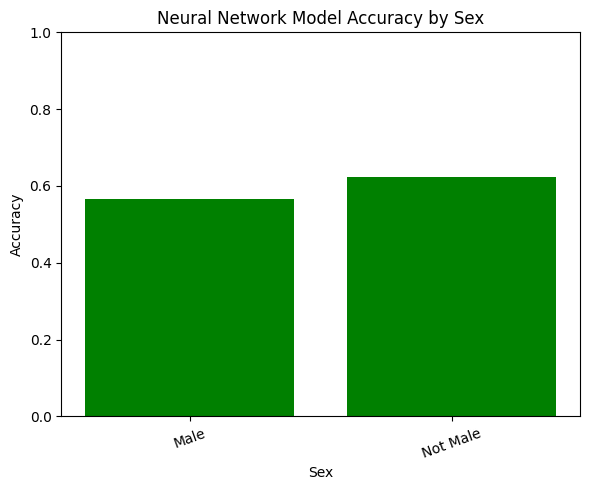

In [45]:
# storing accuracies to plot
sex_accuracies = {
    "Male": accuracy_score(y_test_male, model.predict(X_test_male)),
    "Not Male": accuracy_score(y_test_not_male, model.predict(X_test_not_male))
}

# plotting
plt.figure(figsize=(6,5))
plt.bar(sex_accuracies.keys(), sex_accuracies.values(), color='green')
plt.title("Neural Network Model Accuracy by Sex")
plt.ylabel("Accuracy")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

# saving
plt.savefig("sex_accuracy.png", dpi=300, bbox_inches='tight')

plt.show()

# **Neural Nets with Smote (Synthetic Minority Over-sampling Technique)**

**To observe whether we could use synthetic over-sampling to remedy some of our issues with the poor representation of other offense levels in our data set, we used SMOTE to train neural nets with artifically inflated numbers of violations and felonies.**

In [46]:
# resplitting before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# Using Smote on training data
smote = SMOTE(
    sampling_strategy='not majority',
    random_state=1
)

X_res, y_res = smote.fit_resample(X_train, y_train)

# executing scaling
scaler = StandardScaler()
X_res = scaler.fit_transform(X_res)
X_test = scaler.transform(X_test)

# training
clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='adam',
    max_iter=300,
    random_state=1
)

clf.fit(X_res, y_res)

# evaluation of clf
y_pred = clf.predict(X_test)

In [47]:
y_pred = model.predict(X_test)

# basic accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# balanced accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Accuracy: 0.5764476112804223
Balanced Accuracy: 0.25662162498754804


**We observe no large improvements in accuracy.**

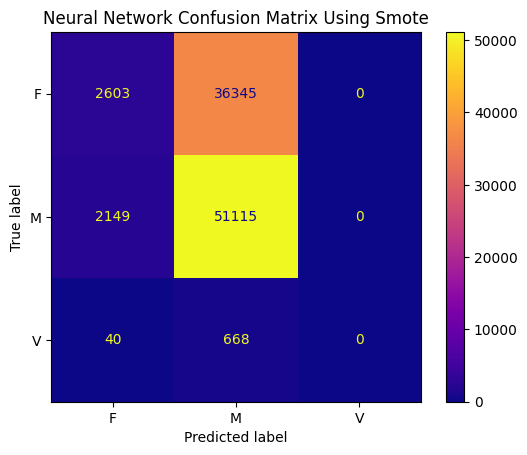

In [48]:
cm = confusion_matrix(y_test, y_pred, labels=['F', 'M', 'V'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['F', 'M', 'V'])
disp.plot(cmap='plasma')
plt.title('Neural Network Confusion Matrix Using Smote')
plt.show()

In [49]:
accuracy_by_group = (
    pd.DataFrame({
        'y_true': y_test,
        'y_pred': y_pred
    })
    .assign(correct=lambda d: d.y_true == d.y_pred)
    .groupby('y_true')['correct']
    .mean()
)

print(accuracy_by_group)

y_true
9    0.000000
F    0.066833
M    0.959654
V    0.000000
Name: correct, dtype: float64


**An extremely high accuracy rate for misdemeanors, but abysmal for everything else.**

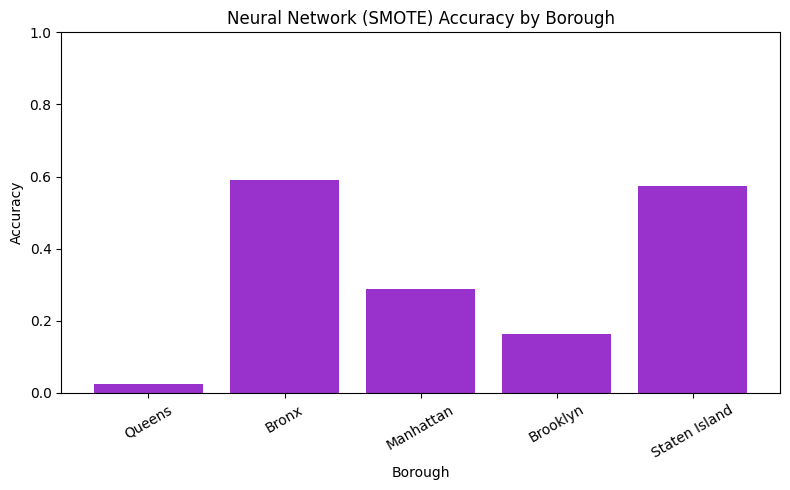

In [50]:
# SMOTE Accuracy by Borough
borough_data_smote = nyar_df.loc[valid_indices, borough_cols].reset_index(drop=True)

X_train_sm, X_test_sm, y_train_sm, y_test_sm, b_train_sm, b_test_sm = train_test_split(
    X_knn, y_knn, borough_data_smote, test_size=0.2, random_state=1, stratify=y_knn
)

smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_res_sm, y_res_sm = smote.fit_resample(X_train_sm, y_train_sm)

scaler_sm        = StandardScaler()
X_res_sm         = scaler_sm.fit_transform(X_res_sm)
X_test_sm_scaled = scaler_sm.transform(X_test_sm)

clf_sm_boro = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', max_iter=300, random_state=1)
clf_sm_boro.fit(X_res_sm, y_res_sm)

queens_test    = b_test_sm['IS_QUEENS']  == 1
bronx_test     = b_test_sm['IS_BRONX']   == 1
manhattan_test = b_test_sm['IS_MANH']   == 1
brooklyn_test  = b_test_sm['IS_BROOK']  == 1
staten_test    = b_test_sm['IS_STATEN'] == 1

X_test_queens    = X_test_sm_scaled[queens_test.values];    y_test_queens    = y_test_sm[queens_test]
X_test_bronx     = X_test_sm_scaled[bronx_test.values];     y_test_bronx     = y_test_sm[bronx_test]
X_test_manhattan = X_test_sm_scaled[manhattan_test.values]; y_test_manhattan = y_test_sm[manhattan_test]
X_test_brooklyn  = X_test_sm_scaled[brooklyn_test.values];  y_test_brooklyn  = y_test_sm[brooklyn_test]
X_test_staten    = X_test_sm_scaled[staten_test.values];    y_test_staten    = y_test_sm[staten_test]

smote_boro_accuracies = {
    'Queens':        accuracy_score(y_test_queens,    clf_sm_boro.predict(X_test_queens)),
    'Bronx':         accuracy_score(y_test_bronx,     clf_sm_boro.predict(X_test_bronx)),
    'Manhattan':     accuracy_score(y_test_manhattan, clf_sm_boro.predict(X_test_manhattan)),
    'Brooklyn':      accuracy_score(y_test_brooklyn,  clf_sm_boro.predict(X_test_brooklyn)),
    'Staten Island': accuracy_score(y_test_staten,    clf_sm_boro.predict(X_test_staten))
}

plt.figure(figsize=(8, 5))
plt.bar(smote_boro_accuracies.keys(), smote_boro_accuracies.values(), color='darkorchid')
plt.title('Neural Network (SMOTE) Accuracy by Borough')
plt.ylabel('Accuracy')
plt.xlabel('Borough')
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('smote_borough_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

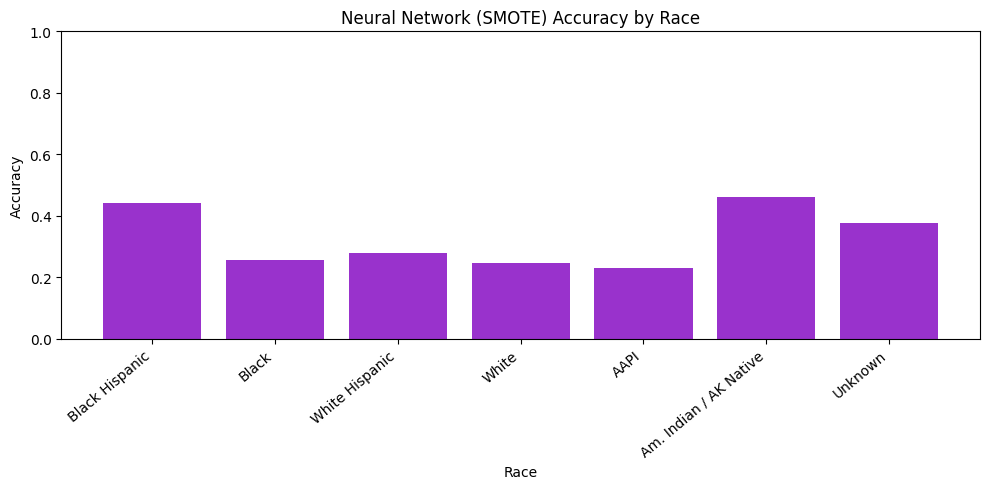

In [51]:
# SMOTE Accuracy by Race
race_data_smote = nyar_df.loc[valid_indices, race_cols].reset_index(drop=True)

X_train_sm, X_test_sm, y_train_sm, y_test_sm, r_train_sm, r_test_sm = train_test_split(
    X_knn, y_knn, race_data_smote, test_size=0.2, random_state=1, stratify=y_knn
)

smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_res_sm, y_res_sm = smote.fit_resample(X_train_sm, y_train_sm)

scaler_sm        = StandardScaler()
X_res_sm         = scaler_sm.fit_transform(X_res_sm)
X_test_sm_scaled = scaler_sm.transform(X_test_sm)

clf_sm_race = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', max_iter=300, random_state=1)
clf_sm_race.fit(X_res_sm, y_res_sm)

black_hisp_test  = r_test_sm['IS_BLACK_HISPANIC'] == 1
black_test       = r_test_sm['IS_BLACK']          == 1
white_hisp_test  = r_test_sm['IS_WHITE_HISPANIC'] == 1
white_test       = r_test_sm['IS_WHITE']          == 1
aapi_test        = r_test_sm['IS_AAPI']           == 1
am_in_ak_na_test = r_test_sm['IS_AM_IN_AK_NA']   == 1
unknown_test     = r_test_sm['RACE_IS_UNKNOWN']   == 1

X_test_bh  = X_test_sm_scaled[black_hisp_test.values];  y_test_bh  = y_test_sm[black_hisp_test]
X_test_b   = X_test_sm_scaled[black_test.values];        y_test_b   = y_test_sm[black_test]
X_test_wh  = X_test_sm_scaled[white_hisp_test.values];  y_test_wh  = y_test_sm[white_hisp_test]
X_test_w   = X_test_sm_scaled[white_test.values];        y_test_w   = y_test_sm[white_test]
X_test_a   = X_test_sm_scaled[aapi_test.values];         y_test_a   = y_test_sm[aapi_test]
X_test_ain = X_test_sm_scaled[am_in_ak_na_test.values];  y_test_ain = y_test_sm[am_in_ak_na_test]
X_test_unk = X_test_sm_scaled[unknown_test.values];      y_test_unk = y_test_sm[unknown_test]

smote_race_accuracies = {
    'Black Hispanic':         accuracy_score(y_test_bh,  clf_sm_race.predict(X_test_bh)),
    'Black':                  accuracy_score(y_test_b,   clf_sm_race.predict(X_test_b)),
    'White Hispanic':         accuracy_score(y_test_wh,  clf_sm_race.predict(X_test_wh)),
    'White':                  accuracy_score(y_test_w,   clf_sm_race.predict(X_test_w)),
    'AAPI':                   accuracy_score(y_test_a,   clf_sm_race.predict(X_test_a)),
    'Am. Indian / AK Native': accuracy_score(y_test_ain, clf_sm_race.predict(X_test_ain)),
    'Unknown':                accuracy_score(y_test_unk, clf_sm_race.predict(X_test_unk))
}

plt.figure(figsize=(10, 5))
plt.bar(smote_race_accuracies.keys(), smote_race_accuracies.values(), color='darkorchid')
plt.title('Neural Network (SMOTE) Accuracy by Race')
plt.ylabel('Accuracy')
plt.xlabel('Race')
plt.ylim(0, 1)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('smote_race_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

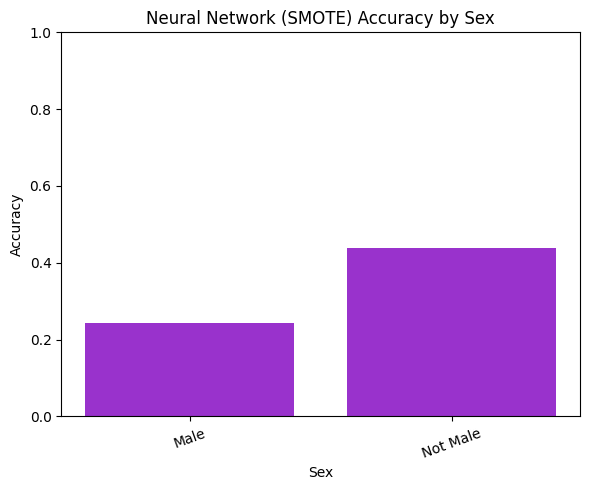

In [52]:
# SMOTE Accuracy by Sex
sex_data_smote = nyar_df.loc[valid_indices, sex_cols].reset_index(drop=True)

X_train_sm, X_test_sm, y_train_sm, y_test_sm, s_train_sm, s_test_sm = train_test_split(
    X_knn, y_knn, sex_data_smote, test_size=0.2, random_state=1, stratify=y_knn
)

smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_res_sm, y_res_sm = smote.fit_resample(X_train_sm, y_train_sm)

scaler_sm        = StandardScaler()
X_res_sm         = scaler_sm.fit_transform(X_res_sm)
X_test_sm_scaled = scaler_sm.transform(X_test_sm)

clf_sm_sex = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', max_iter=300, random_state=1)
clf_sm_sex.fit(X_res_sm, y_res_sm)

male_test     = s_test_sm['IS_MALE'] == 1
not_male_test = s_test_sm['IS_MALE'] == 0

X_test_male     = X_test_sm_scaled[male_test.values];     y_test_male     = y_test_sm[male_test]
X_test_not_male = X_test_sm_scaled[not_male_test.values]; y_test_not_male = y_test_sm[not_male_test]

smote_sex_accuracies = {
    'Male':     accuracy_score(y_test_male,     clf_sm_sex.predict(X_test_male)),
    'Not Male': accuracy_score(y_test_not_male, clf_sm_sex.predict(X_test_not_male))
}

plt.figure(figsize=(6, 5))
plt.bar(smote_sex_accuracies.keys(), smote_sex_accuracies.values(), color='darkorchid')
plt.title('Neural Network (SMOTE) Accuracy by Sex')
plt.ylabel('Accuracy')
plt.xlabel('Sex')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('smote_sex_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# **Model Comparisons**

In [61]:
# Rebuild each model's predictions on a shared split for fair comparison
# Using the same X_scaled, y, X, and valid_indices already in memory

X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Random Forest (tuned, balanced)
rf_cmp = RandomForestClassifier(
    random_state=42, class_weight='balanced',
    n_estimators=200, max_depth=10, min_samples_leaf=5
)
rf_cmp.fit(X_train_cmp, y_train_cmp)
y_pred_rf_cmp = rf_cmp.predict(X_test_cmp)

# KNN (best k = 19)
knn_cmp = KNeighborsClassifier(n_neighbors=19)
knn_cmp.fit(X_train_cmp, y_train_cmp)
y_pred_knn_cmp = knn_cmp.predict(X_test_cmp)

# Logistic Regression
lr_cmp = sk.linear_model.LogisticRegression(max_iter=5000)
lr_cmp.fit(X_train_cmp, y_train_cmp)
y_pred_lr_cmp = lr_cmp.predict(X_test_cmp)

# Neural Network (plain MLP)
mlp_cmp = MLPClassifier(hidden_layer_sizes=(62, 34), solver='adam', alpha=1e-4, max_iter=200, random_state=1)
mlp_cmp.fit(X_train_cmp, y_train_cmp)
y_pred_mlp_cmp = mlp_cmp.predict(X_test_cmp)

# Neural Network + SMOTE (needs raw unscaled X so pipeline stays clean)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote_cmp = SMOTE(sampling_strategy='not majority', random_state=1)
X_res_cmp, y_res_cmp = smote_cmp.fit_resample(X_train_raw, y_train_raw)
scaler_cmp    = StandardScaler()
X_res_cmp_sc  = scaler_cmp.fit_transform(X_res_cmp)
X_test_raw_sc = scaler_cmp.transform(X_test_raw)
mlp_smote_cmp = MLPClassifier(hidden_layer_sizes=(64, 32), solver='adam', max_iter=300, random_state=1)
mlp_smote_cmp.fit(X_res_cmp_sc, y_res_cmp)
y_pred_smote_cmp = mlp_smote_cmp.predict(X_test_raw_sc)

print('All comparison models fitted.')

All comparison models fitted.


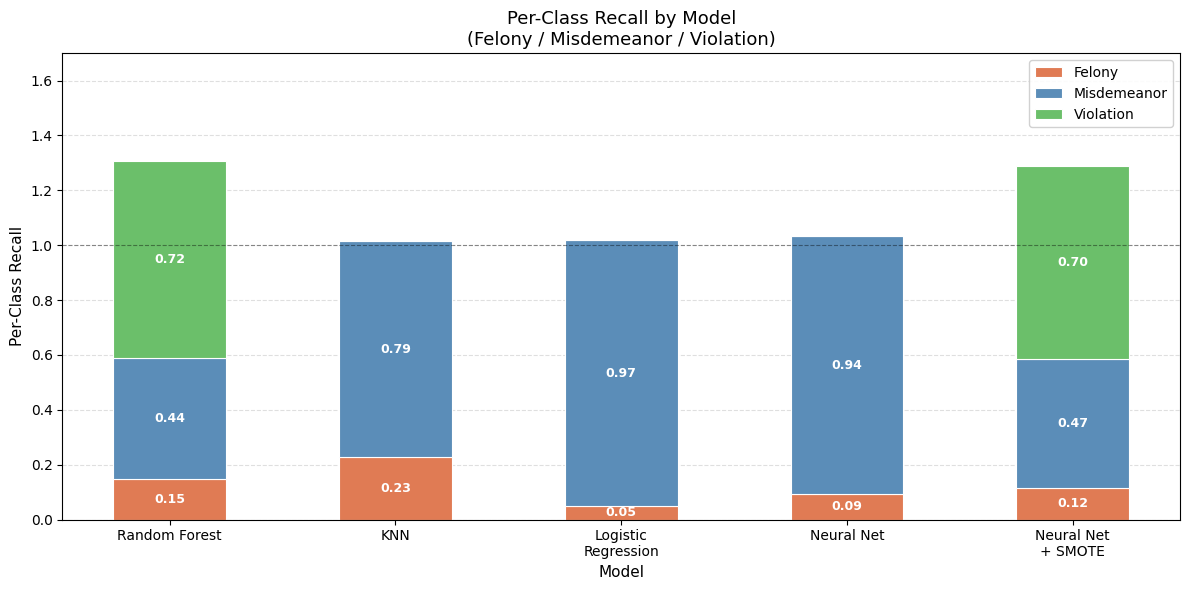

In [63]:
# ── Per-class balanced accuracy stacked bar chart ───────────────────────────
from sklearn.metrics import confusion_matrix

model_names = ['Random Forest', 'KNN', 'Logistic\nRegression', 'Neural Net', 'Neural Net\n+ SMOTE']
y_trues = [y_test_cmp, y_test_cmp, y_test_cmp, y_test_cmp, y_test_raw]
y_preds = [y_pred_rf_cmp, y_pred_knn_cmp, y_pred_lr_cmp, y_pred_mlp_cmp, y_pred_smote_cmp]

labels        = ['F', 'M', 'V']
label_display = ['Felony', 'Misdemeanor', 'Violation']
colors        = ['#E07B54', '#5B8DB8', '#6BBF6A']

def per_class_recall(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    return (cm / row_sums).diagonal()

recalls = np.array([per_class_recall(yt, yp, labels) for yt, yp in zip(y_trues, y_preds)])

x         = np.arange(len(model_names))
bar_width = 0.5
fig, ax   = plt.subplots(figsize=(12, 6))
bottoms   = np.zeros(len(model_names))

for i, (cls_label, color) in enumerate(zip(label_display, colors)):
    vals = recalls[:, i]
    b = ax.bar(x, vals, bar_width, bottom=bottoms, color=color,
               label=cls_label, edgecolor='white', linewidth=0.8)
    for rect, val in zip(b, vals):
        if val > 0.04:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + rect.get_height() / 2,
                f'{val:.2f}',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Per-Class Recall', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_title('Per-Class Recall by Model\n(Felony / Misdemeanor / Violation)', fontsize=13)
ax.set_ylim(0, 1.7)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison_stacked.png', dpi=300, bbox_inches='tight')
plt.show()